# NHL Tracking Data Calculations

This notebook uses the available mock tracking CSV to practice simple hockey data analysis. The ideas are intentionally small: clean the tracking data, calculate basic skating metrics, compare teams, and estimate which player is closest to the puck at each timestamp.

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.float_format', '{:.4f}'.format)

data = pd.read_csv('trackingData_expanded.csv')

# The mock CSV has one unicode minus sign, so normalize it before numeric conversion.
numeric_cols = ['Location.X', 'Location.Y', 'velocity_x', 'velocity_y', 'UTCTime']
for col in numeric_cols:
    data[col] = (
        data[col]
        .astype(str)
        .str.replace('−', '-', regex=False)
        .pipe(pd.to_numeric, errors='coerce')
    )

data['OnPlayingSurface'] = data['OnPlayingSurface'].astype(bool)
running = data[data['ClockState'] == 'ClockStateRunning'].copy()

players = running[running['entityType'] == 'player'].copy()
puck = running[running['entityType'] == 'puck'].copy()

players['elapsed_seconds'] = (players['UTCTime'] - players['UTCTime'].min()) / 1000
puck['elapsed_seconds'] = (puck['UTCTime'] - puck['UTCTime'].min()) / 1000

player_count = players['player'].nunique()
print(f'Rows in file: {len(data)}')
print(f'Running rows used: {len(running)}')
print(f'Players tracked: {player_count}')
display(players)

Rows in file: 195
Running rows used: 195
Players tracked: 14


,timeStamp,entityType,player,team,Location.X,Location.Y,velocity_x,velocity_y,UTCTime,ClockState,OnPlayingSurface,elapsed_seconds
0,1,player,Matthews,Toronto,60,40,1.5000,0.3000,1000,ClockStateRunning,True,0.0000
1,1,player,Marner,Toronto,55,35,1.2000,-0.2000,1000,ClockStateRunning,True,0.0000
2,1,player,Nylander,Toronto,65,38,0.8000,0.5000,1000,ClockStateRunning,True,0.0000
3,1,player,Rielly,Toronto,30,50,0.3000,-0.2000,1000,ClockStateRunning,True,0.0000
4,1,player,Brodie,Toronto,25,45,-0.1000,0.1000,1000,ClockStateRunning,True,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...
189,15,player,Draisaitl,Edmonton,34,53,-1.6000,-0.3000,15000,ClockStateRunning,True,14.0000
190,15,player,Bouchard,Edmonton,31,59,-1.4000,-0.1000,15000,ClockStateRunning,True,14.0000
191,15,player,Nurse,Edmonton,36,51,-1.1000,-0.2000,15000,ClockStateRunning,True,14.0000
192,15,player,Ekholm,Edmonton,40,49,-1.0000,-0.3000,15000,ClockStateRunning,True,14.0000


## Basic Skating Metrics

Distance, speed, and acceleration are calculated between each player's consecutive tracking points. `UTCTime` is stored in milliseconds, so the notebook converts it to seconds before calculating speed.

In [92]:
players = players.sort_values(['player', 'UTCTime']).copy()

players['dx'] = players.groupby('player')['Location.X'].diff()
players['dy'] = players.groupby('player')['Location.Y'].diff()
players['dt_seconds'] = players.groupby('player')['UTCTime'].diff() / 1000
players['distance'] = np.sqrt(players['dx']**2 + players['dy']**2)
players['speed'] = players['distance'] / players['dt_seconds']
players['acceleration'] = players.groupby('player')['speed'].diff() / players['dt_seconds']

player_summary = (
    players.groupby(['team', 'player'], as_index=False)
    .agg(
        tracking_points=('timeStamp', 'count'),
        total_distance=('distance', 'sum'),
        average_speed=('speed', 'mean'),
        max_speed=('speed', 'max'),
        max_acceleration=('acceleration', 'max')
    )
    .fillna(0)
)

# A simple ranking score: reward max speed first, then acceleration.
player_summary['simple_skater_score'] = (
    player_summary['max_speed'].rank(pct=True) * 0.5
    + player_summary['max_acceleration'].rank(pct=True) * 0.3
    + player_summary['total_distance'].rank(pct=True) * 0.2
)

player_summary = player_summary.sort_values('simple_skater_score', ascending=False)
display(player_summary)

,team,player,tracking_points,total_distance,average_speed,max_speed,max_acceleration,simple_skater_score
11,Toronto,Nylander,15,90.1207,6.4372,45.2769,43.8627,1.0000
9,Toronto,Marner,15,68.4834,4.8917,29.1204,27.7062,0.8714
13,Toronto,Tavares,12,63.8630,5.8057,28.0713,26.6571,0.8000
2,Edmonton,Ekholm,15,70.4520,5.0323,21.1896,18.9536,0.7714
0,Edmonton,Bouchard,15,77.7421,5.5530,19.2354,16.9993,0.7357
7,Toronto,Brodie,15,47.3232,3.3802,19.1050,17.6908,0.6214
1,Edmonton,Draisaitl,15,72.5451,5.1818,17.4642,14.3020,0.6143
5,Edmonton,Nurse,15,72.7897,5.1993,15.6525,13.4164,0.5143
4,Edmonton,McDavid,7,50.3434,8.3906,16.7631,13.6008,0.5000
12,Toronto,Rielly,15,40.9402,2.9243,13.1529,11.7387,0.3571


## Team-Level View

This rolls the player metrics up by team. With real tracking data, this could be a starting point for comparing pace, pressure, or workload.

In [93]:
team_summary = (
    player_summary.groupby('team', as_index=False)
    .agg(
        players=('player', 'count'),
        team_distance=('total_distance', 'sum'),
        average_player_speed=('average_speed', 'mean'),
        fastest_player_speed=('max_speed', 'max')
    )
    .sort_values('team_distance', ascending=False)
)

display(team_summary)

,team,players,team_distance,average_player_speed,fastest_player_speed
0,Edmonton,7,370.7390,4.5627,21.1896
1,Toronto,7,313.1447,3.5209,45.2769


## Simple Puck Proximity / Possession Estimate

A beginner-friendly way to estimate possession from tracking data is to mark the player closest to the puck at each timestamp. This is not the same as official possession, but it is a useful first experiment.

In [94]:
puck_positions = puck[['timeStamp', 'Location.X', 'Location.Y']].rename(
    columns={'Location.X': 'puck_x', 'Location.Y': 'puck_y'}
)

player_puck = players.merge(puck_positions, on='timeStamp', how='inner')
player_puck['distance_to_puck'] = np.sqrt(
    (player_puck['Location.X'] - player_puck['puck_x'])**2
    + (player_puck['Location.Y'] - player_puck['puck_y'])**2
)

closest_to_puck = (
    player_puck.sort_values(['timeStamp', 'distance_to_puck'])
    .groupby('timeStamp', as_index=False)
    .first()[['timeStamp', 'team', 'player', 'distance_to_puck']]
)

team_possession_estimate = (
    closest_to_puck['team']
    .value_counts(normalize=True)
    .mul(100)
    .rename_axis('team')
    .reset_index(name='estimated_puck_control_pct')
)

display(closest_to_puck)
display(team_possession_estimate)

,timeStamp,team,player,distance_to_puck
0,1,Toronto,Matthews,2.2361
1,2,Toronto,Matthews,3.1623
2,3,Toronto,Nylander,2.8284
3,4,Toronto,Tavares,2.2361
4,5,Toronto,Tavares,3.0000
5,6,Toronto,Tavares,4.1231
6,7,Edmonton,McDavid,1.4142
7,8,Edmonton,Ekholm,2.8284
8,9,Edmonton,Nurse,4.2426
9,10,Toronto,Rielly,5.0000


,team,estimated_puck_control_pct
0,Toronto,80.0000
1,Edmonton,20.0000


## Quick Visual Checks

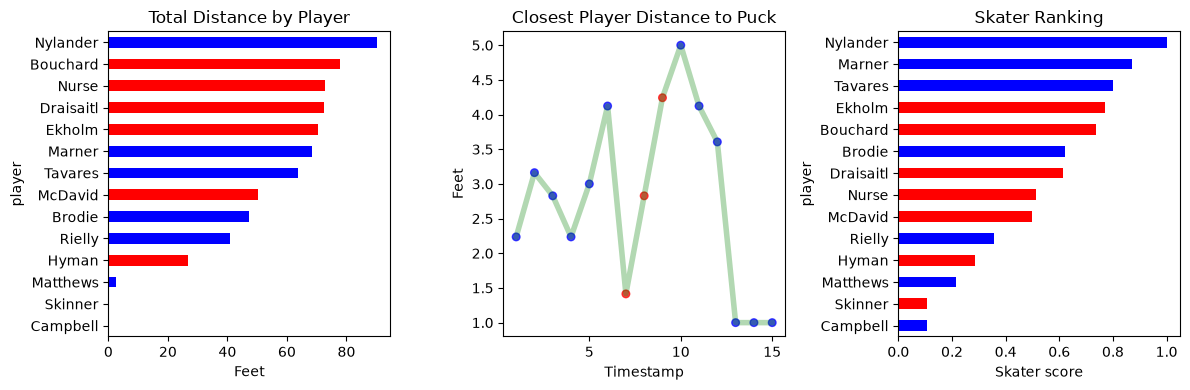

In [95]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Color mapping for teams
team_colors = player_summary['team'].unique()
color_map = {team: color for team, color in zip(sorted(team_colors), ['red', 'blue'])}

# Total Distance by Player
df1 = player_summary.sort_values('total_distance')
colors1 = [color_map[team] for team in df1['team']]
df1.plot(
    x='player', y='total_distance', kind='barh', ax=axes[0], legend=False, color=colors1
)
axes[0].set_title('Total Distance by Player')
axes[0].set_xlabel('Feet')

# Closest Player Distance to Puck - colored by team
closest_to_puck_sorted = closest_to_puck.sort_values('timeStamp')
colors_puck = [color_map[team] for team in closest_to_puck_sorted['team']]
axes[1].plot(closest_to_puck_sorted['timeStamp'], closest_to_puck_sorted['distance_to_puck'], 
             color='green', alpha=0.3, linewidth=4)
axes[1].scatter(closest_to_puck_sorted['timeStamp'], closest_to_puck_sorted['distance_to_puck'],
                c=colors_puck, s=30, alpha=0.7)

axes[1].set_title('Closest Player Distance to Puck')
axes[1].set_xlabel('Timestamp')
axes[1].set_ylabel('Feet')

# Skater Ranking
df2 = player_summary.sort_values('simple_skater_score', ascending=True)
colors2 = [color_map[team] for team in df2['team']]
df2.plot(
    x='player', y='simple_skater_score', kind='barh', ax=axes[2], legend=False, color=colors2
)
axes[2].set_title('Skater Ranking')
axes[2].set_xlabel('Skater score')

plt.tight_layout()
plt.show()